# Variance-Exploding (VE) Diffusion — Companion Workbook

This notebook is a companion to the *Flow Matching for Audio Generation* assignment.
This workbook walks a similar pipeline using
**variance-exploding (VE) diffusion*, which was covered in class.

The key ideas here parallel the slides:
- Noise is added as $x_t = x_0 + \sigma_t\,\varepsilon$ (the signal is never destroyed, just buried)
- We train a network in **x-prediction** mode: the model directly outputs the denoised
  spectrogram $\hat{x}_0$
- Sampling follows the DDIM / probability-flow ODE, which has the same iterative
  "predict-and-re-noise" structure as DDPM

By the end you will have a complete, working VE diffusion model: data loading,
a UNet denoiser, training with CFG dropout, and DDIM-style Euler sampling.

In [ ]:
# Install missing deps (torch / torchaudio are pre-installed on Colab)
!pip install -q librosa tqdm

import os, sys, math, copy, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import IPython.display as ipd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


---
## Background: Variance-Exploding Diffusion (this notebook)

This is the formulation shown in class, where the forward process adds noise on top of the data:
$$x_t = x_0 + \sigma(t)\,\varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

We use a **linear noise schedule**:
$$\sigma(t) = \sigma_{\min} + (\sigma_{\max} - \sigma_{\min})\,t$$

with $\sigma_{\min} = 0.002$ and $\sigma_{\max} = 80$. At $t=1$ the noise level is
$80\times$ the typical signal amplitude — the signal is completely buried.

### x-Prediction

Our denoiser $\mu_\theta(x_t, t, p)$ is trained to predict the clean data $x_0$ directly.
**Training objective** (mean-squared error in data space):
$$\mathcal{L}(\theta) = \mathbb{E}_{x_0,\,t,\,\varepsilon}\!\left[\|\mu_\theta(x_t, t, p) - x_0\|^2\right]$$

### Sampling: DDIM / Probability-Flow ODE

The probability-flow ODE for VE diffusion (Song et al., 2021) is:
$$\frac{dx}{dt} = \frac{\dot{\sigma}(t)}{\sigma(t)}\,(x_t - \hat{x}_0)$$

where $\dot{\sigma} = d\sigma/dt$ and $\hat{x}_0 = \mu_\theta(x_t, t, p)$.
Discretizing this with step size $\Delta t$ gives the **DDIM update rule**:
$$\boxed{x_{t - \Delta t} = \hat{x}_0 + \frac{\sigma(t-\Delta t)}{\sigma(t)}\,(x_t - \hat{x}_0)}$$

**Interpretation**: at each step, predict $\hat{x}_0$, compute the estimated noise direction
$\hat{\varepsilon} = (x_t - \hat{x}_0)/\sigma(t)$, then re-noise to the next (lower) level $\sigma(t-\Delta t)$.
At the final step $\sigma(0) \approx 0$, so the output is essentially just $\hat{x}_0$.

---
## Data Pipeline (Inlined from `dataset.py`)

In [2]:
# ── Audio / STFT constants ────────────────────────────────────────────────────
SR            = 16_000
CHUNK_SAMPLES = int(SR * 0.5)        # 0.5-second clips → 8 000 samples
N_FFT         = 256
HOP_LENGTH    = 128
FREQ_BINS     = N_FFT // 2 + 1       # 129
TIME_FRAMES   = CHUNK_SAMPLES // HOP_LENGTH + 1  # 63

# Power-law magnitude compression:  X_norm = |X|^0.5 · exp(j·∠X)
# Compresses the wide dynamic range without needing pre-computed statistics.
ALPHA = 0.5
BETA  = 1.0

def _normalize_powerlaw(stft, alpha=ALPHA, beta=BETA):
    mag   = stft.abs().clamp(min=1e-9)
    phase = torch.angle(stft)
    mag_c = beta * mag.pow(alpha)
    return torch.complex(mag_c * torch.cos(phase), mag_c * torch.sin(phase))

def _denormalize_powerlaw(stft, alpha=ALPHA, beta=BETA):
    mag_c = stft.abs().clamp(min=1e-9)
    phase = torch.angle(stft)
    mag   = (mag_c / beta).pow(1.0 / alpha)
    return torch.complex(mag * torch.cos(phase), mag * torch.sin(phase))

def wav_to_spec(path):
    """Load a WAV file and return a power-law compressed spectrogram (2, 129, 63)."""
    audio, sr = torchaudio.load(str(path))
    if sr != SR:
        audio = torchaudio.functional.resample(audio, sr, SR)
    audio = audio[0]
    chunk = audio[:CHUNK_SAMPLES]
    if len(chunk) < CHUNK_SAMPLES:
        chunk = F.pad(chunk, (0, CHUNK_SAMPLES - len(chunk)))
    window = torch.hann_window(N_FFT)
    stft   = torch.stft(chunk, n_fft=N_FFT, hop_length=HOP_LENGTH,
                        window=window, return_complex=True, center=True)
    stft   = _normalize_powerlaw(stft)
    spec   = torch.stack([stft.real, stft.imag], dim=0)  # (2, F, T)
    if spec.shape[2] > TIME_FRAMES:
        spec = spec[:, :, :TIME_FRAMES]
    elif spec.shape[2] < TIME_FRAMES:
        spec = F.pad(spec, (0, TIME_FRAMES - spec.shape[2]))
    return spec

def spec_to_audio(spec):
    """Convert a (2, 129, 63) spectrogram back to a waveform via ISTFT."""
    stft_norm = torch.complex(spec[0], spec[1])
    stft      = _denormalize_powerlaw(stft_norm)
    window    = torch.hann_window(N_FFT, device=spec.device)
    return torch.istft(stft, n_fft=N_FFT, hop_length=HOP_LENGTH,
                       window=window, center=True, length=CHUNK_SAMPLES)

class NSynthSpecDataset(Dataset):
    """NSynth spectrogram dataset with optional RAM caching."""
    def __init__(self, audio_dir, max_files=None, instrument_filter=None, cache=True):
        files = sorted(Path(audio_dir).glob('*.wav'))
        if instrument_filter:
            files = [f for f in files if f.stem.startswith(instrument_filter)]
            print(f"Instrument filter '{instrument_filter}': {len(files)} files match")
        if max_files and len(files) > max_files:
            rng = random.Random(42)
            rng.shuffle(files)
            files = files[:max_files]
        self.files  = files
        self._cache = [None] * len(files) if cache else None
        print(f"NSynthSpecDataset: {len(self.files)} files  (cache: {'on' if cache else 'off'})")

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        if self._cache is not None and self._cache[idx] is not None:
            return self._cache[idx]
        path  = self.files[idx]
        spec  = wav_to_spec(path)
        pitch = torch.tensor(int(path.stem.split('-')[-2]), dtype=torch.long)
        item  = (spec, pitch)
        if self._cache is not None:
            self._cache[idx] = item
        return item

---
## Model: UNet Denoiser (Inlined from `model.py`)

We reuse the same UNet2D architecture as the flow matching assignment.
The key difference is the **interpretation**: in VE diffusion the model predicts
the clean spectrogram $\hat{x}_0$, not a velocity field.

The architecture is unchanged, as only the training objective and sampling procedure differ.

In [4]:
NULL_PITCH = 128   # reserved index for unconditional token (CFG)

# ── Shared building blocks ────────────────────────────────────────────────────

class SinusoidalEmbedding(nn.Module):
    """Fixed sinusoidal embedding of scalar time t ∈ [0, 1]."""
    def __init__(self, dim):
        super().__init__()
        half  = dim // 2
        freqs = torch.exp(-math.log(10_000) * torch.arange(half).float() / max(half-1, 1))
        self.register_buffer('freqs', freqs)
    def forward(self, t):
        emb = t[:, None] * self.freqs[None]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

def _make_t_emb(t_dim):
    """Time-conditioning MLP: sinusoidal → 2-layer MLP → (B, t_dim)."""
    return nn.Sequential(
        SinusoidalEmbedding(t_dim),
        nn.Linear(t_dim, t_dim * 2), nn.SiLU(),
        nn.Linear(t_dim * 2, t_dim),
    )

class ResBlock(nn.Module):
    """Pre-norm residual conv block with additive time+pitch conditioning."""
    def __init__(self, channels, t_dim, groups=8):
        super().__init__()
        self.norm1  = nn.GroupNorm(groups, channels)
        self.conv1  = nn.Conv2d(channels, channels, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, channels)
        self.norm2  = nn.GroupNorm(groups, channels)
        self.conv2  = nn.Conv2d(channels, channels, 3, padding=1)
        self.act    = nn.SiLU()
    def forward(self, x, cond):
        h = self.act(self.conv1(self.norm1(x)))
        h = h + self.t_proj(self.act(cond))[:, :, None, None]
        h = self.act(self.conv2(self.norm2(h)))
        return x + h

# ── UNetDenoiser ──────────────────────────────────────────────────────────────

class UNetDenoiser(nn.Module):
    """
    2-level UNet that maps (x_t, t, pitch) → x̂_0.

    Architecturally identical to UNet2DFlowNet from model.py; only the
    training objective and sampling differ (x-prediction vs velocity).

    Default config: hidden=32, t_dim=32 → ~213 k parameters.
    """
    def __init__(self, hidden=32, t_dim=32):
        super().__init__()
        C, g = hidden, min(8, hidden)
        self.t_emb     = _make_t_emb(t_dim)
        self.pitch_emb = nn.Embedding(NULL_PITCH + 1, t_dim)

        # Encoder
        self.input_proj = nn.Conv2d(2, C, 3, padding=1)
        self.enc1       = ResBlock(C,     t_dim, groups=g)
        self.down1      = nn.AvgPool2d(2)
        self.chan_up1   = nn.Conv2d(C, C, 1)
        self.enc2       = ResBlock(C,     t_dim, groups=g)
        self.down2      = nn.AvgPool2d(2)
        self.chan_up2   = nn.Conv2d(C, C * 2, 1)
        self.bottleneck = ResBlock(C * 2, t_dim, groups=min(8, C * 2))

        # Decoder
        self.merge1 = nn.Conv2d(C * 2 + C, C, 3, padding=1)
        self.dec1   = ResBlock(C, t_dim, groups=g)
        self.merge2 = nn.Conv2d(C + C,     C, 3, padding=1)
        self.dec2   = ResBlock(C, t_dim, groups=g)

        self.output_proj = nn.Sequential(nn.GroupNorm(g, C), nn.SiLU(), nn.Conv2d(C, 2, 1))

    def forward(self, x, t, pitch):
        """
        Args:
            x     : (B, 2, F, T)  noisy spectrogram x_t
            t     : (B,)          timestep ∈ [0, 1]
            pitch : (B,)          MIDI pitch label (long), NULL_PITCH for unconditional
        Returns:
            x̂_0   : (B, 2, F, T)  predicted clean spectrogram
        """
        cond = self.t_emb(t) + self.pitch_emb(pitch)

        # Encoder
        h  = self.input_proj(x)
        s1 = self.enc1(h, cond)
        h  = self.chan_up1(self.down1(s1))
        s2 = self.enc2(h, cond)
        h  = self.chan_up2(self.down2(s2))
        h  = self.bottleneck(h, cond)

        # Decoder
        h = F.interpolate(h, size=s2.shape[2:], mode='bilinear', align_corners=False)
        h = self.dec1(self.merge1(torch.cat([h, s2], dim=1)), cond)
        h = F.interpolate(h, size=s1.shape[2:], mode='bilinear', align_corners=False)
        h = self.dec2(self.merge2(torch.cat([h, s1], dim=1)), cond)

        return self.output_proj(h)   # (B, 2, F, T) — predicted x̂_0

# ── Instantiate ───────────────────────────────────────────────────────────────
model    = UNetDenoiser(hidden=24, t_dim=32).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"UNetDenoiser: {n_params:,} parameters")

UNetDenoiser: 125,202 parameters


---
## The VE Noise Schedule and Forward Process

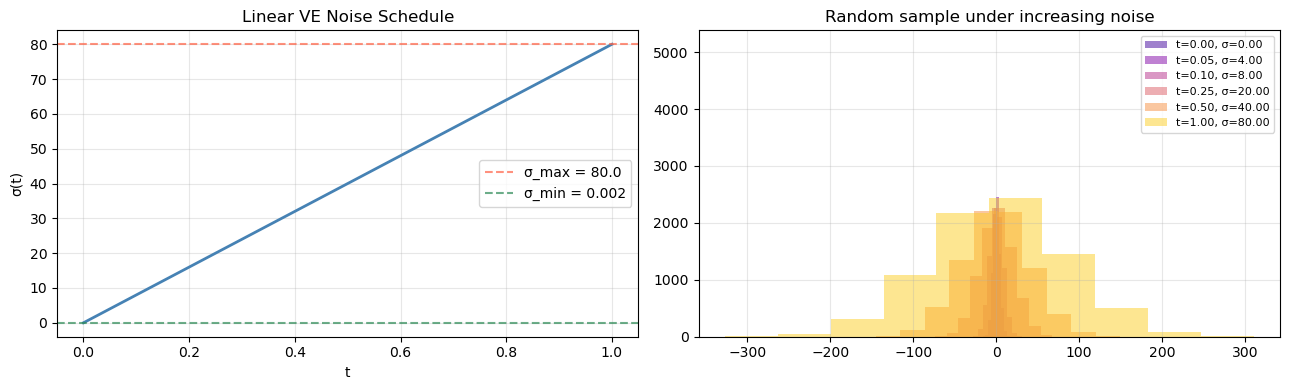

In [12]:
# ── Noise schedule ────────────────────────────────────────────────────────────
SIGMA_MIN = 0.002
SIGMA_MAX = 80.0

def get_sigma(t, sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX):
    """
    Linear noise schedule: σ(t) = σ_min + (σ_max - σ_min) · t.
    Works with scalars or (B,) tensors.
    """
    return sigma_min + (sigma_max - sigma_min) * t

def ve_forward(x0, t, sigma_min=SIGMA_MIN, sigma_max=SIGMA_MAX):
    """
    VE forward process: x_t = x_0 + σ(t) · ε.

    Args:
        x0 : (B, 2, F, T)  clean spectrograms
        t  : (B,)           timesteps ∈ [0, 1]
    Returns:
        x_t   : (B, 2, F, T) noisy spectrograms
        noise : (B, 2, F, T) the noise added (useful for monitoring)
    """
    sigma = get_sigma(t, sigma_min, sigma_max)   # (B,)
    noise = torch.randn_like(x0)
    x_t   = x0 + sigma[:, None, None, None] * noise
    return x_t, noise

# ── Visualise the schedule ─────────────────────────────────────────────────────
ts     = np.linspace(0, 1, 300)
sigmas = [get_sigma(float(t)) for t in ts]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(ts, sigmas, 'steelblue', lw=2)
ax.axhline(SIGMA_MAX, color='tomato',  ls='--', alpha=0.7, label=f'σ_max = {SIGMA_MAX}')
ax.axhline(SIGMA_MIN, color='seagreen',ls='--', alpha=0.7, label=f'σ_min = {SIGMA_MIN}')
ax.set_xlabel('t'); ax.set_ylabel('σ(t)')
ax.set_title('Linear VE Noise Schedule'); ax.legend(); ax.grid(alpha=0.3)

# Show how a synthetic "signal" is corrupted at increasing t
ax = axes[1]
torch.manual_seed(7)
x0_demo = torch.zeros(1, 2, FREQ_BINS, TIME_FRAMES)
x0_demo[0, 0, 20:80, 5:55] = 1.5   # rectangular patch = synthetic signal

t_vals = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_vals)))
for color, t_val in zip(colors, t_vals):
    sig = get_sigma(float(t_val))
    x_t = x0_demo + sig * torch.randn_like(x0_demo)
    row = x_t[0, 0].numpy().flatten()   # mean over freq → (TIME_FRAMES,)
    ax.hist(row, color=color, alpha=0.5, label=f't={t_val:.2f}, σ={sig:.2f}')


ax.set_title('Random sample under increasing noise'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
## Load Data

In [ ]:
# ── Download NSynth validation set (if not already present) ──────────────────
DATA_ROOT = '/content/nsynth'
VALID_DIR = f'{DATA_ROOT}/nsynth-valid/audio'

if not os.path.exists(VALID_DIR):
    print("Downloading nsynth-valid (~1.4 GB) ...")
    os.makedirs(DATA_ROOT, exist_ok=True)
    !wget -q -O /tmp/nsynth-valid.jsonwav.tar.gz \
        http://download.magenta.tensorflow.org/datasets/nsynth/nsynth-valid.jsonwav.tar.gz
    !tar -xzf /tmp/nsynth-valid.jsonwav.tar.gz -C {DATA_ROOT}
    print("Done!")
else:
    print(f"Data already at {VALID_DIR}")

# ── Build dataset ─────────────────────────────────────────────────────────────
INSTRUMENT = 'keyboard'   # change to 'guitar', 'mallet', 'string', etc.
MAX_FILES  = 2000         # ~5-min training run on Colab T4

train_ds = NSynthSpecDataset(VALID_DIR, max_files=MAX_FILES,
                              instrument_filter=INSTRUMENT)
loader   = DataLoader(train_ds, batch_size=32, shuffle=True,
                      num_workers=2, pin_memory=True)
print(f"\nBatches per epoch: {len(loader)}")

4485.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
4558.36s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Done!
Instrument filter 'keyboard': 2404 files match
NSynthSpecDataset: 2000 files  (cache: on)

Batches per epoch: 63


---
## Training

### Loss Function

The training objective is **MSE in x-prediction space**:
$$\mathcal{L}(\theta) = \mathbb{E}_{x_0, t, \varepsilon}\!\left[\|\mu_\theta(x_0 + \sigma(t)\varepsilon,\; t,\; p) - x_0\|^2\right]$$

Steps for each mini-batch:
1. Sample random timesteps $t \sim \text{Uniform}(0,1)$
2. Corrupt the spectrogram: $x_t = x_0 + \sigma(t)\,\varepsilon$
3. CFG dropout: replace some pitch labels with `NULL_PITCH` with probability $p_{\text{uncond}}$
4. Predict the clean data: $\hat{x}_0 = \mu_\theta(x_t, t, p)$
5. Compute MSE: $\|\hat{x}_0 - x_0\|^2$

> **Note on weighting**: a common variant weights the loss by $1/\sigma(t)^2$ so each noise
> level contributes equally. Here we'll keep it unweighted!

In [14]:
def ve_loss(model, x_data, pitch, p_uncond=0.1):
    """
    VE diffusion training loss (x-prediction MSE).

    Args:
        model   : UNetDenoiser  (x_t, t, pitch) → x̂_0
        x_data  : (B, 2, F, T)  clean spectrograms
        pitch   : (B,)           MIDI pitch labels (long)
        p_uncond: probability of CFG null dropout

    Returns:
        loss : scalar tensor (differentiable, ready for .backward())
    """
    B = x_data.shape[0]

    # 1. Random timesteps (logit-normal concentrates near t=0.5 → balanced training)
    t = torch.sigmoid(torch.randn(B, device=x_data.device))

    # 2. VE forward process: x_t = x_0 + σ(t) · ε
    x_t, _ = ve_forward(x_data, t)

    # 3. CFG dropout: randomly replace pitch with null token
    pitch = pitch.clone()
    mask  = torch.rand(B, device=x_data.device) < p_uncond
    pitch[mask] = NULL_PITCH

    # 4. Predict and compute loss
    x0_pred = model(x_t, t, pitch)
    return F.mse_loss(x0_pred, x_data)

In [15]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS  = 100
LR        = 3e-4

model     = UNetDenoiser(hidden=24, t_dim=32).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# ── Training loop ─────────────────────────────────────────────────────────────
model.train()
for epoch in range(N_EPOCHS):
    total_loss = 0.0
    for x_data, pitch in loader:
        x_data, pitch = x_data.to(device), pitch.to(device)

        optimizer.zero_grad(set_to_none=True)
        loss = ve_loss(model, x_data, pitch, p_uncond=0.1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    if (epoch + 1) % 10 == 0 or epoch == 0:
        avg = total_loss / len(loader)
        print(f"Epoch {epoch+1:3d}/{N_EPOCHS} | loss = {avg:.4f}")

model.eval()
print("\nTraining complete.")

Epoch   1/100 | loss = 0.3115
Epoch  10/100 | loss = 0.2910
Epoch  20/100 | loss = 0.2899
Epoch  30/100 | loss = 0.2890
Epoch  40/100 | loss = 0.2877
Epoch  50/100 | loss = 0.2861
Epoch  60/100 | loss = 0.2849
Epoch  70/100 | loss = 0.2837
Epoch  80/100 | loss = 0.2835
Epoch  90/100 | loss = 0.2824
Epoch 100/100 | loss = 0.2819

Training complete.


---
## Sampling

### Euler / DDIM Sampler

We integrate the reverse-time probability-flow ODE from $t=1$ (pure noise) to $t=0$ (clean data).

At each step $t \to t - \Delta t$:
1. **Predict** $\hat{x}_0 = \mu_\theta(x_t, t, p)$
2. **DDIM update**: $x_{t-\Delta t} = \hat{x}_0 + \dfrac{\sigma(t-\Delta t)}{\sigma(t)}(x_t - \hat{x}_0)$

The ratio $\sigma(t-\Delta t)/\sigma(t) < 1$ shrinks the residual $(x_t - \hat{x}_0)$ toward zero,
gradually removing the noise. At the final step $\sigma(0) = \sigma_{\min} \approx 0$, the
output converges to $\hat{x}_0$ directly.

**Initial noise**: start from $x_1 \sim \mathcal{N}(0,\, \sigma_{\max}^2 I)$ to match the VE prior.

In [16]:
@torch.no_grad()
def euler_sample_ve(model, x_init, pitches, n_steps=50):
    """
    DDIM / probability-flow ODE Euler sampler for VE diffusion.

    Args:
        model   : UNetDenoiser
        x_init  : (B, 2, F, T)  starting noise — sample from N(0, σ_max² I)
        pitches : (B,)           MIDI pitch labels (long)
        n_steps : number of denoising steps (more steps → smoother, slower)

    Returns:
        x : (B, 2, F, T)  generated spectrograms
    """
    x  = x_init.clone()
    B  = x.shape[0]
    ts = torch.linspace(1.0, 0.0, n_steps + 1, device=x.device)  # t_0=1 … t_N=0

    for i in range(n_steps):
        t_cur  = ts[i].item()
        t_prev = ts[i + 1].item()

        sig_cur  = get_sigma(t_cur)
        sig_prev = get_sigma(t_prev)

        # Predict clean data
        t_batch = torch.full((B,), t_cur, device=x.device)
        x0_hat  = model(x, t_batch, pitches)

        # DDIM update: re-noise to the next (lower) sigma level
        x = x0_hat + (sig_prev / sig_cur) * (x - x0_hat)

    return x

# ── Quick sanity check ────────────────────────────────────────────────────────
torch.manual_seed(0)
test_noise   = torch.randn(2, 2, FREQ_BINS, TIME_FRAMES, device=device) * SIGMA_MAX
test_pitches = torch.tensor([60, 72], dtype=torch.long, device=device)

x_gen = euler_sample_ve(model, test_noise, test_pitches, n_steps=20)
print(f"Output shape : {x_gen.shape}")
print(f"Output range : [{x_gen.min():.2f}, {x_gen.max():.2f}]")

Output shape : torch.Size([2, 2, 129, 63])
Output range : [-5.31, 6.97]


### Classifier-Free Guidance (CFG)

CFG amplifies pitch conditioning by blending the conditioned and unconditioned predictions:
$$\hat{x}_0^{\text{guided}} = \hat{x}_0^{\text{uncond}} + s\,(\hat{x}_0^{\text{cond}} - \hat{x}_0^{\text{uncond}})$$

The guidance scale $s > 1$
sharpens the conditioning; $s = 1$ recovers standard sampling.

In [17]:
@torch.no_grad()
def cfg_sample_ve(model, x_init, pitches, n_steps=50, guidance_scale=1.0):
    """
    CFG-guided DDIM sampler for VE diffusion.

    Args:
        guidance_scale: 1.0 = no guidance; > 1 = amplify pitch conditioning.
    """
    x      = x_init.clone()
    B      = x.shape[0]
    p_null = torch.full_like(pitches, NULL_PITCH)
    ts     = torch.linspace(1.0, 0.0, n_steps + 1, device=x.device)

    for i in range(n_steps):
        t_cur  = ts[i].item()
        t_prev = ts[i + 1].item()

        sig_cur  = get_sigma(t_cur)
        sig_prev = get_sigma(t_prev)

        t_batch  = torch.full((B,), t_cur, device=x.device)
        x0_cond  = model(x, t_batch, pitches)

        if guidance_scale == 1.0:
            x0_hat = x0_cond
        else:
            x0_uncond = model(x, t_batch, p_null)
            x0_hat    = x0_uncond + guidance_scale * (x0_cond - x0_uncond)

        # DDIM update
        x = x0_hat + (sig_prev / sig_cur) * (x - x0_hat)

    return x

---
## Generate and Listen

In [49]:
NOTE_NAMES = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']

def pitch_name(p):
    return f"{NOTE_NAMES[p % 12]}{p // 12 - 1}"

# ── Generate a C major scale (C4 D4 E4 F4 G4 A4 B4 C5) ───────────────────────
scale_pitches = [60, 62, 64, 65, 67, 69, 71, 72]
torch.manual_seed(42)

noise_batch = torch.randn(len(scale_pitches), 2, FREQ_BINS, TIME_FRAMES,
                           device=device) * SIGMA_MAX
pitch_batch = torch.tensor(scale_pitches, dtype=torch.long, device=device)

specs = cfg_sample_ve(model, noise_batch, pitch_batch, n_steps=50, guidance_scale=5.0)

# ── Decode, normalise, concatenate, and play ──────────────────────────────────
audio_clips = []
for spec, p in zip(specs.cpu(), scale_pitches):
    audio = spec_to_audio(spec)
    audio = audio / (audio.abs().max() + 1e-6)  # peak normalise
    audio_clips.append(audio)

concat = torch.cat(audio_clips)
labels = ', '.join(pitch_name(p) for p in scale_pitches)
print(f"C major scale: {labels}")
ipd.display(ipd.Audio(concat.numpy(), rate=SR))

C major scale: C4, D4, E4, F4, G4, A4, B4, C5


In [19]:
# ── Compare guidance scales on a single pitch ─────────────────────────────────
target_pitch = 60   # middle C

for gs in [1.0, 3.0, 6.0, 10.0]:
    torch.manual_seed(42)
    noise  = torch.randn(1, 2, FREQ_BINS, TIME_FRAMES, device=device) * SIGMA_MAX
    pitch  = torch.tensor([target_pitch], dtype=torch.long, device=device)
    out    = cfg_sample_ve(model, noise, pitch, n_steps=50, guidance_scale=gs)
    audio  = spec_to_audio(out[0].cpu())
    audio  = audio / (audio.abs().max() + 1e-6)
    print(f"guidance_scale = {gs:4.1f}")
    ipd.display(ipd.Audio(audio.numpy(), rate=SR))

guidance_scale =  1.0


guidance_scale =  3.0


guidance_scale =  6.0


guidance_scale = 10.0


---
## A Note on Model Equivalences


Given a trained x-prediction VE model, you can always re-express its output as:

| Quantity | Formula |
|---|---|
| Estimated noise | $\hat{\varepsilon} = (x_t - \hat{x}_0)\,/\,\sigma(t)$ |
| Score function  | $\nabla_x \log p_t = -\hat{\varepsilon}\,/\,\sigma(t) = (\hat{x}_0 - x_t)\,/\,\sigma(t)^2$ |

This is why modern frameworks (EDM, k-diffusion) often provide converter utilities —
the same neural network, trained once, can serve as a score function, an ε-predictor,
or an x-predictor depending on which wrapper you apply.